1. Data Loading and Cleaning: Load the datasets and handle missing values, outliers,
and inconsistencies.

In [1]:
import pandas as pd 

df = pd.read_csv('../data/Project_Phase1.csv')
print(df.head())



   syn_error_rate  connection_time  destination_same_source_port_rate  \
0             0.0                0                               0.01   
1             1.0                0                               0.00   
2             1.0                0                               0.00   
3             1.0                0                               0.00   
4             1.0                0                               0.00   

   destination_different_server_rate connection_status  connection_count  \
0                               0.00                SF                 2   
1                               0.07                S0               242   
2                               0.08                S0               234   
3                               0.08                S0               140   
4                               0.07                S0               126   

   destination_server_different_host_rate  suspicious_activity protocol  \
0                            

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14036 entries, 0 to 14035
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   syn_error_rate                          14036 non-null  float64
 1   connection_time                         14036 non-null  int64  
 2   destination_same_source_port_rate       14036 non-null  float64
 3   destination_different_server_rate       14036 non-null  float64
 4   connection_status                       14036 non-null  str    
 5   connection_count                        14036 non-null  int64  
 6   destination_server_different_host_rate  14036 non-null  float64
 7   suspicious_activity                     14036 non-null  int64  
 8   protocol                                14036 non-null  str    
 9   server_different_host_rate              14036 non-null  float64
 10  destination_server_syn_error_rate       14036 non-null  float64
 11  

In [3]:
df.isna().sum()

syn_error_rate                            0
connection_time                           0
destination_same_source_port_rate         0
destination_different_server_rate         0
connection_status                         0
connection_count                          0
destination_server_different_host_rate    0
suspicious_activity                       0
protocol                                  0
server_different_host_rate                0
destination_server_syn_error_rate         0
destination_host_server_count             0
destination_same_server_rate              0
fragment_errors                           0
compromised_count                         0
source_bytes                              0
service_type                              0
destination_syn_error_rate                0
same_server_rate                          0
reset_error_rate                          0
server_request_count                      0
destination_server_reset_error_rate       0
server_reset_error_rate         

In [4]:
num_classes = []
for col in df.select_dtypes(include=['int64','float64']).columns:
    num_classes.append(col)

cat_classes = []
for col in df.select_dtypes(include=['str','object']).columns:
    cat_classes.append(col)

In [5]:
print("Numerical classes:", num_classes)
print("Categorical classes:", cat_classes)

Numerical classes: ['syn_error_rate', 'connection_time', 'destination_same_source_port_rate', 'destination_different_server_rate', 'connection_count', 'destination_server_different_host_rate', 'suspicious_activity', 'server_different_host_rate', 'destination_server_syn_error_rate', 'destination_host_server_count', 'destination_same_server_rate', 'fragment_errors', 'compromised_count', 'source_bytes', 'destination_syn_error_rate', 'same_server_rate', 'reset_error_rate', 'server_request_count', 'destination_server_reset_error_rate', 'server_reset_error_rate', 'server_syn_error_rate', 'destination_bytes', 'guest_login', 'authentication_status', 'destination_host_count', 'destination_reset_error_rate', 'different_server_rate']
Categorical classes: ['connection_status', 'protocol', 'service_type', 'class']


1- Numerical features   
    - histogram 
    - boxplot 
    - scatter plot 
    - spearman corrleation 
    - corrleation ration between (each numerical and each object)

2- cat features 
    - Uncertainty Coefficient
    - bar plot 
    - chi square 


In [6]:
print(len(num_classes))

27


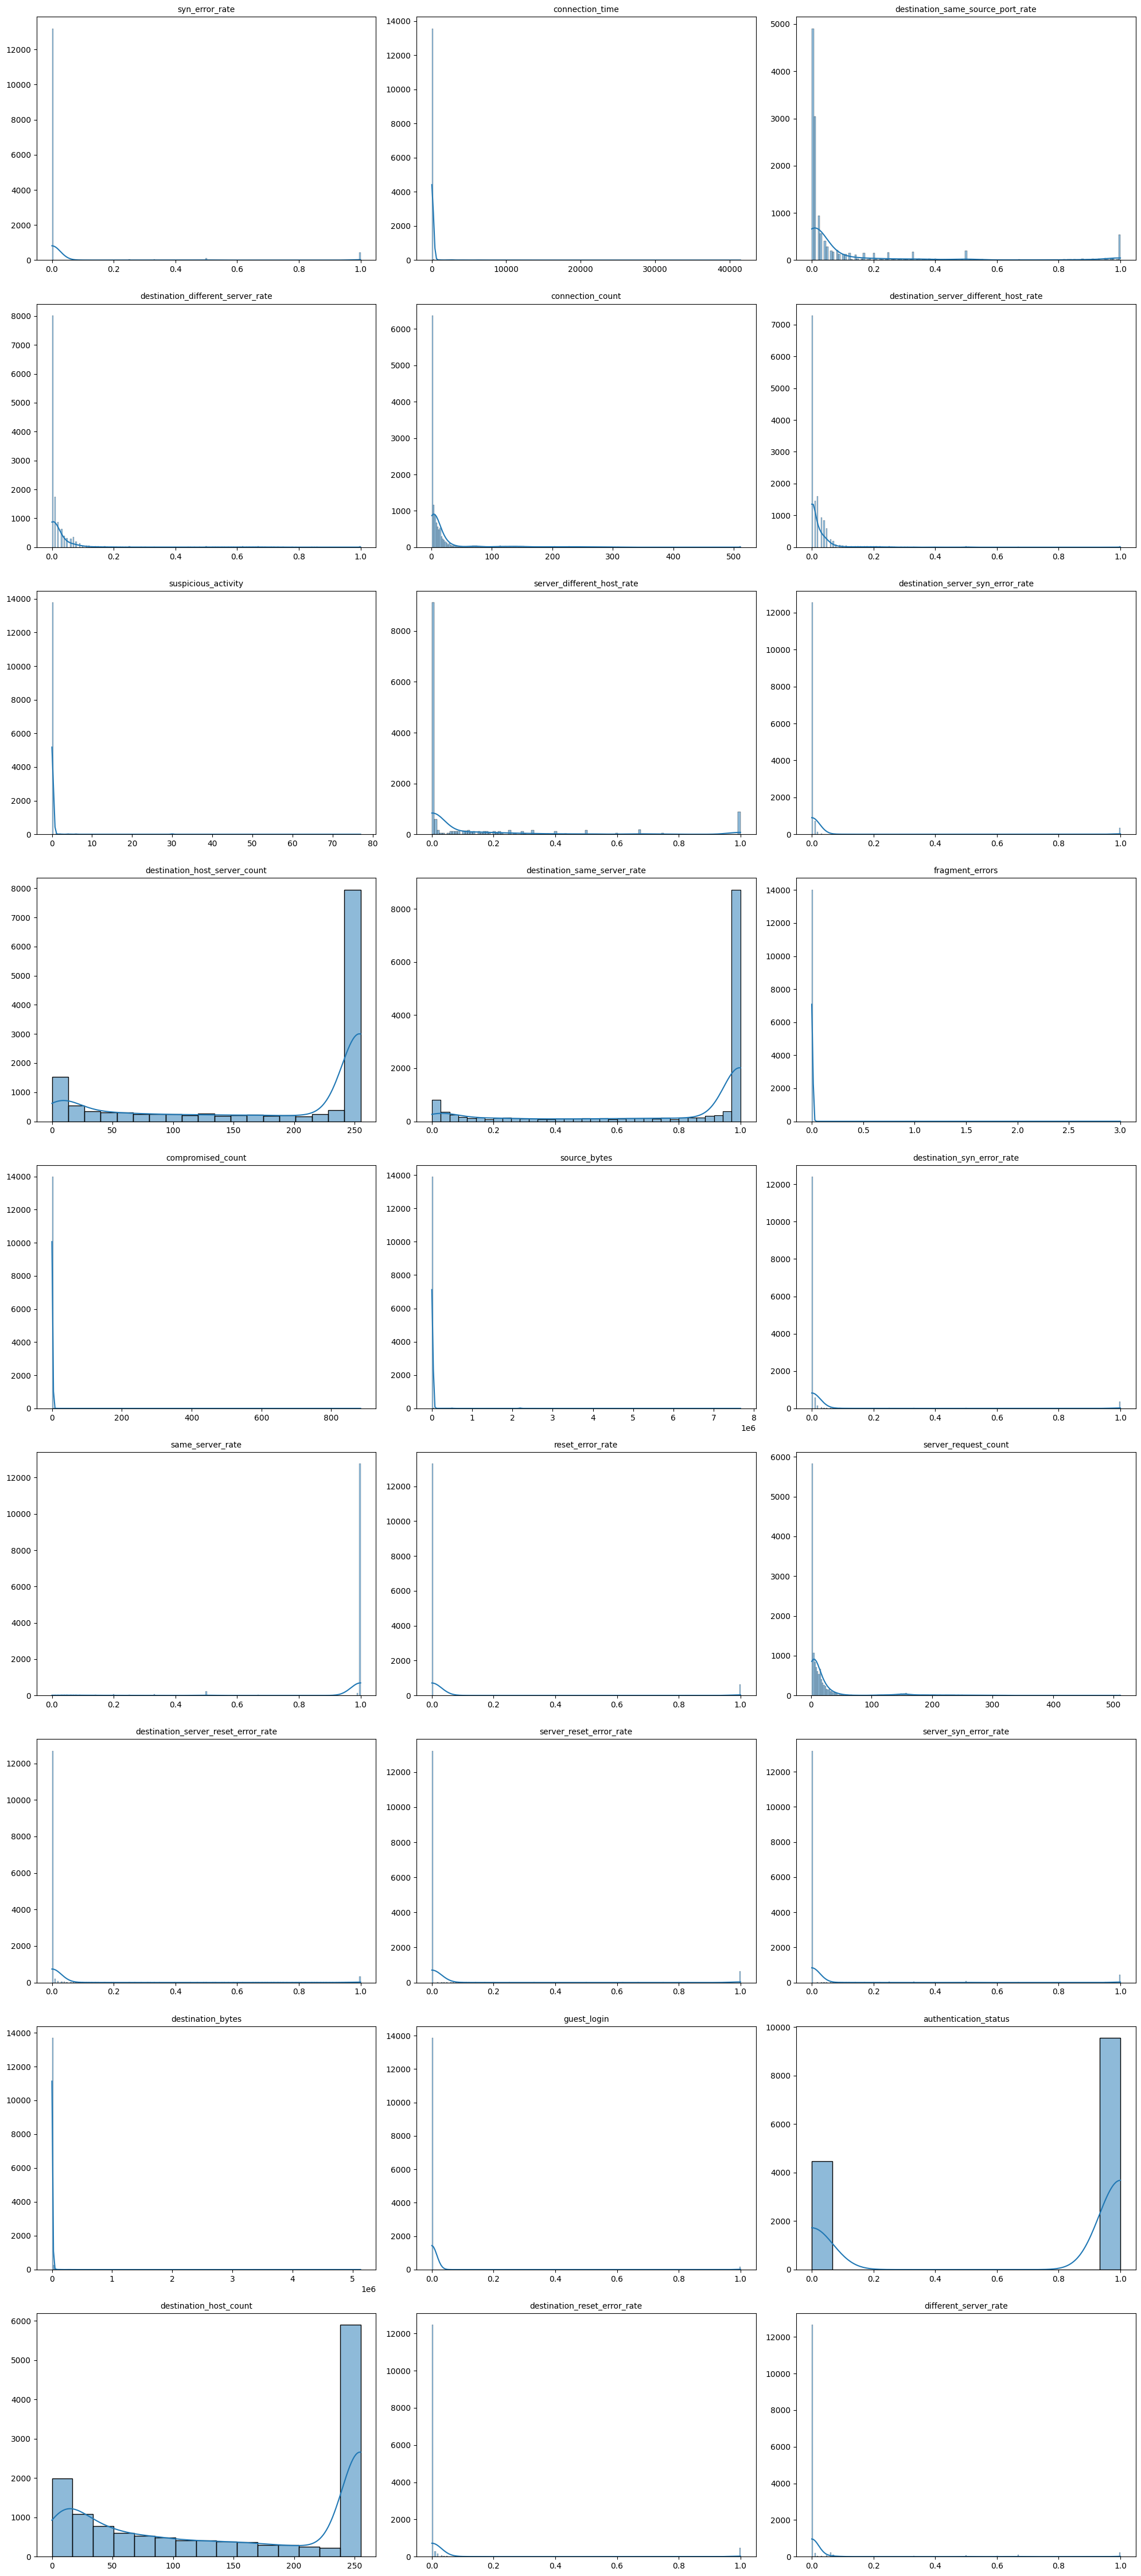

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3

n_rows = math.ceil(len(num_classes) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))


axes = axes.flatten()

for i, col in enumerate(num_classes):
    
    sns.histplot(df[col], kde=True, ax=axes[i])
    
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()

plt.show()

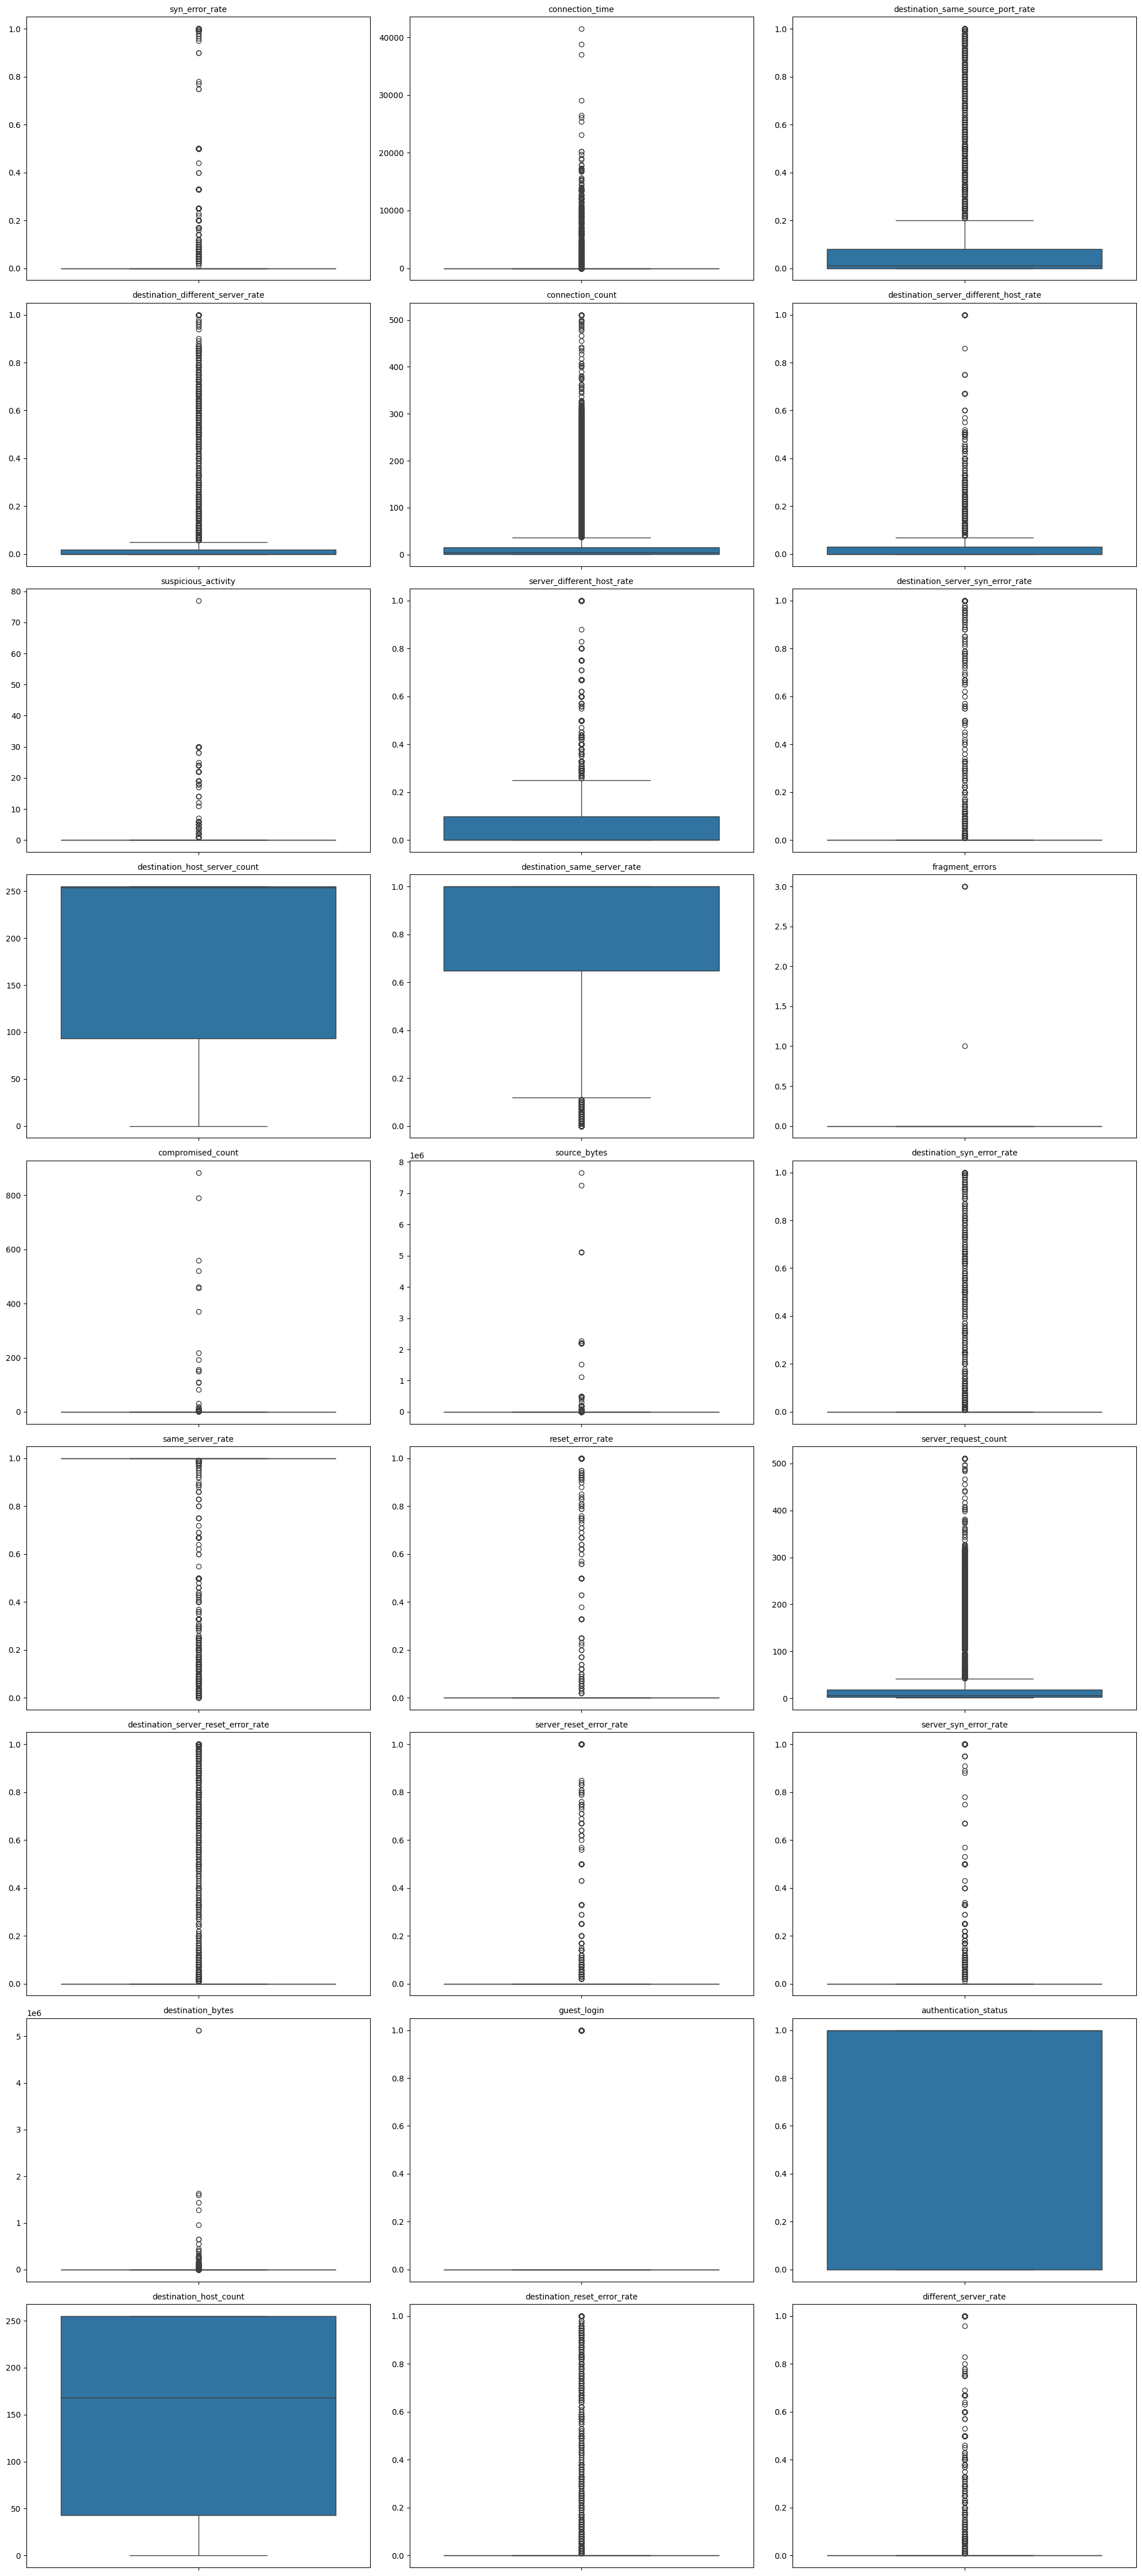

In [8]:
n_cols = 3

n_rows = math.ceil(len(num_classes) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))


axes = axes.flatten()

for i, col in enumerate(num_classes):
    
    sns.boxplot(df[col], ax=axes[i])
    
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()

plt.show()

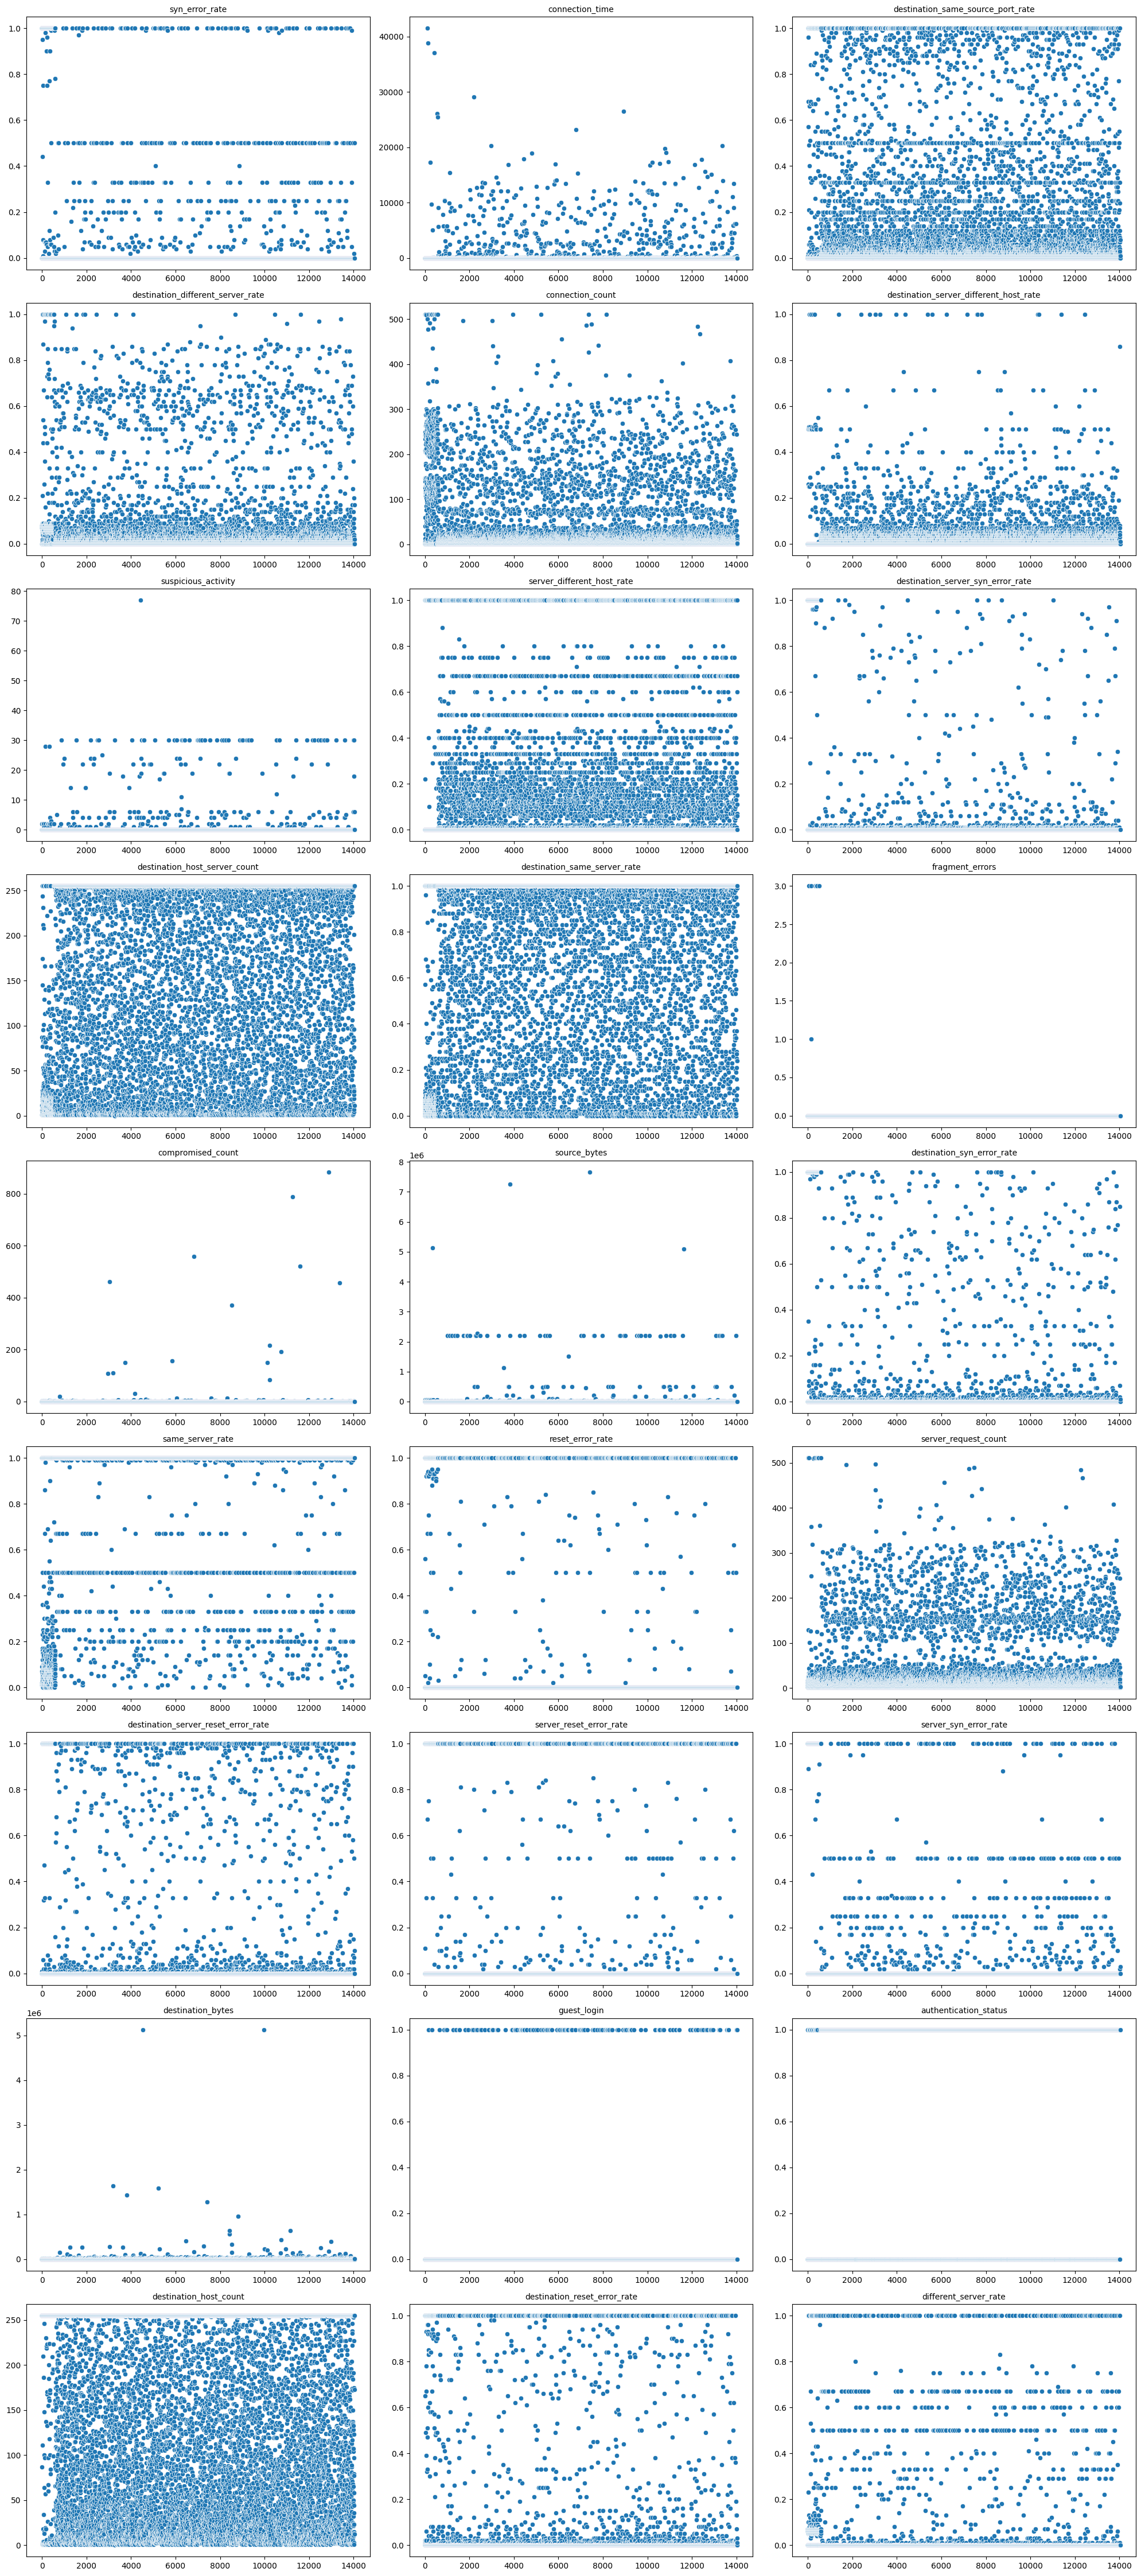

In [9]:
n_cols = 3

n_rows = math.ceil(len(num_classes) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))


axes = axes.flatten()

for i, col in enumerate(num_classes):
    
    sns.scatterplot(df[col], ax=axes[i])
    
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()

plt.show()

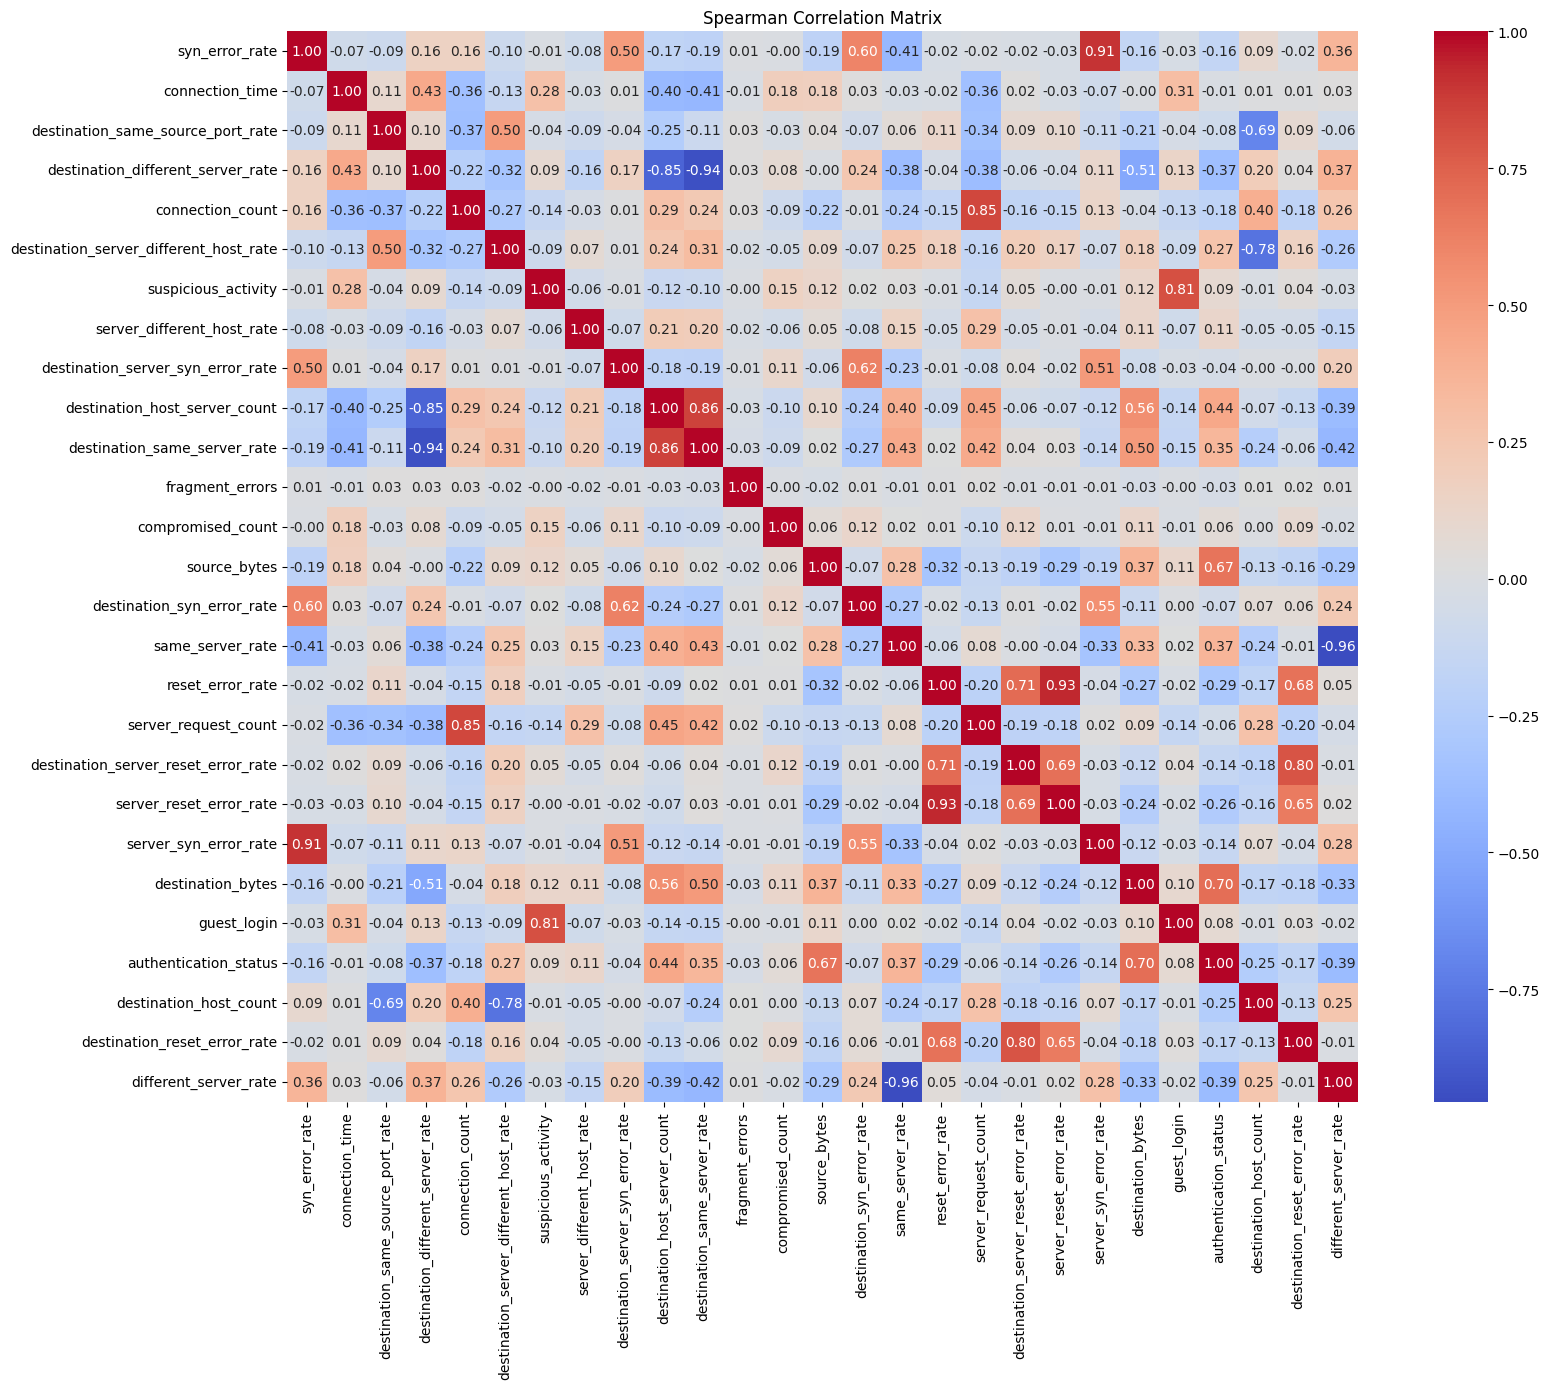

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

spearman_corr = df[num_classes].corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [11]:
import numpy as np


def correlation_ratio(categories, measurements):
    
    categories = pd.factorize(categories)[0]
    
    cat_num = np.max(categories) + 1
    
    y_avg = np.mean(measurements)
    
    numerator = 0
    denominator = np.sum((measurements - y_avg) ** 2)

    for i in range(cat_num):
        cat_measures = measurements[categories == i]
        
        if len(cat_measures) == 0:
            continue
        
        cat_avg = np.mean(cat_measures)
        
        numerator += len(cat_measures) * (cat_avg - y_avg) ** 2

    eta = np.sqrt(numerator / denominator)
    
    return eta


num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns


results = []

for cat in cat_cols:
    for num in num_cols:
        
        eta = correlation_ratio(df[cat], df[num])
        
        results.append({
            'Categorical': cat,
            'Numerical': num,
            'Eta': eta
        })

eta_df = pd.DataFrame(results)


eta_df = eta_df.sort_values(by='Eta', ascending=False)

print(eta_df)

/tmp/ipykernel_18241/1258716858.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


          Categorical                Numerical       Eta
16  connection_status         reset_error_rate  0.984748
19  connection_status  server_reset_error_rate  0.983361
76       service_type              guest_login  0.958311
0   connection_status           syn_error_rate  0.941614
20  connection_status    server_syn_error_rate  0.931790
..                ...                      ...       ...
98              class     server_request_count  0.010949
11  connection_status          fragment_errors  0.007276
93              class        compromised_count  0.005406
87              class      suspicious_activity  0.005336
94              class             source_bytes  0.001484

[108 rows x 3 columns]


In [12]:
eta_df.to_csv('../data/correlation_ratios.csv', index=False)

In [13]:
eta_df.info()

<class 'pandas.DataFrame'>
Index: 108 entries, 16 to 94
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Categorical  108 non-null    str    
 1   Numerical    108 non-null    str    
 2   Eta          108 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.4 KB


In [14]:
eta_df.head()

,Categorical,Numerical,Eta
16,connection_status,reset_error_rate,0.984748
19,connection_status,server_reset_error_rate,0.983361
76,service_type,guest_login,0.958311
0,connection_status,syn_error_rate,0.941614
20,connection_status,server_syn_error_rate,0.931790


In [15]:
from sklearn.metrics import mutual_info_score

# Entropy function
def entropy(x):
    probs = pd.Series(x).value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

# Uncertainty coefficient U(Y|X)
def uncertainty_coefficient(x, y):
    mi = mutual_info_score(x, y)
    h = entropy(y)
    
    if h == 0:
        return 0
    
    return mi / h

In [16]:
uc_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        
        uc_matrix.loc[col1, col2] = uncertainty_coefficient(
            df[col1],
            df[col2]
        )

uc_matrix = uc_matrix.astype(float)

uc_matrix

,connection_status,protocol,service_type,class
connection_status,0.693147,0.025757,0.048336,0.360706
protocol,0.035662,0.693147,0.217361,0.026824
service_type,0.200470,0.651123,0.693147,0.431590
class,0.150305,0.008073,0.043362,0.693147


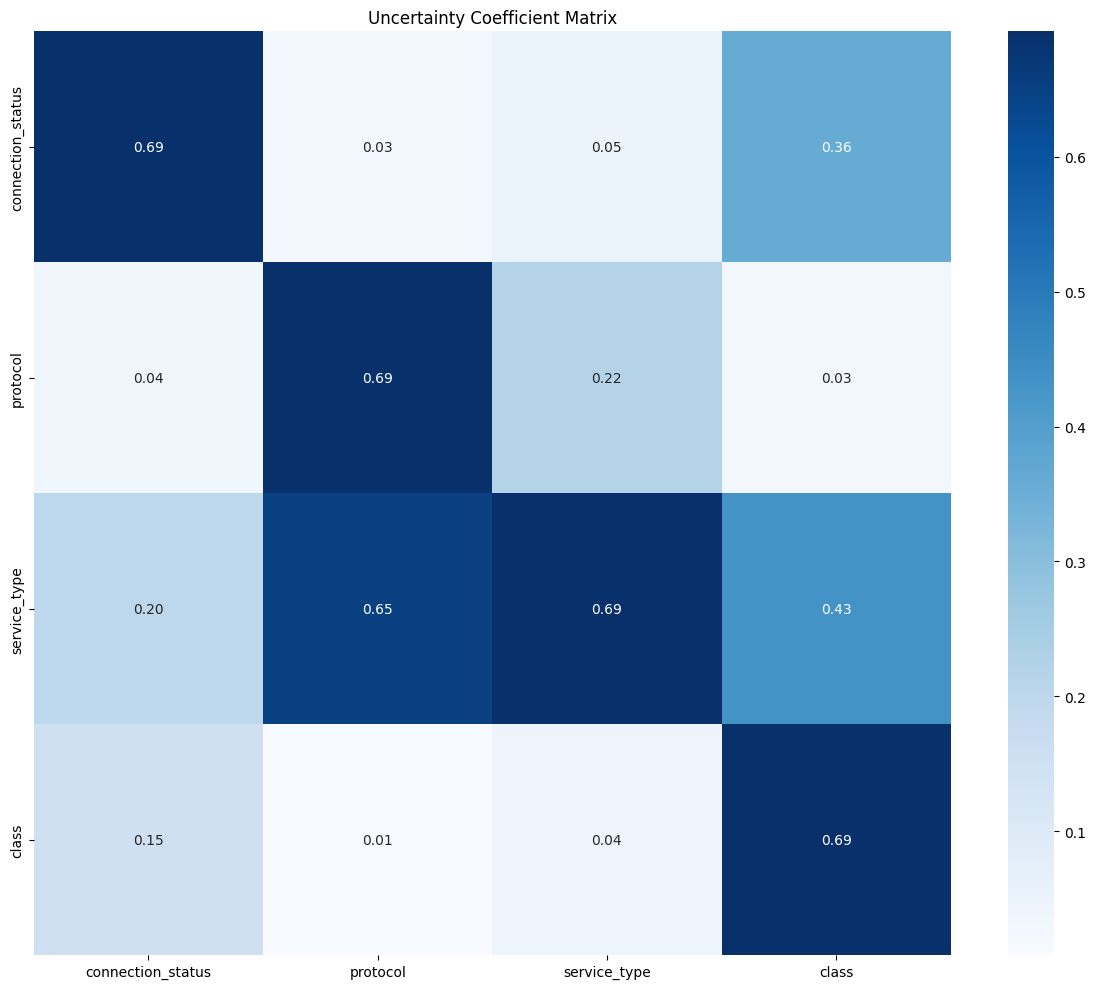

In [17]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    uc_matrix,
    annot=True,
    cmap='Blues',
    fmt=".2f"
)

plt.title("Uncertainty Coefficient Matrix")

plt.tight_layout()
plt.show()

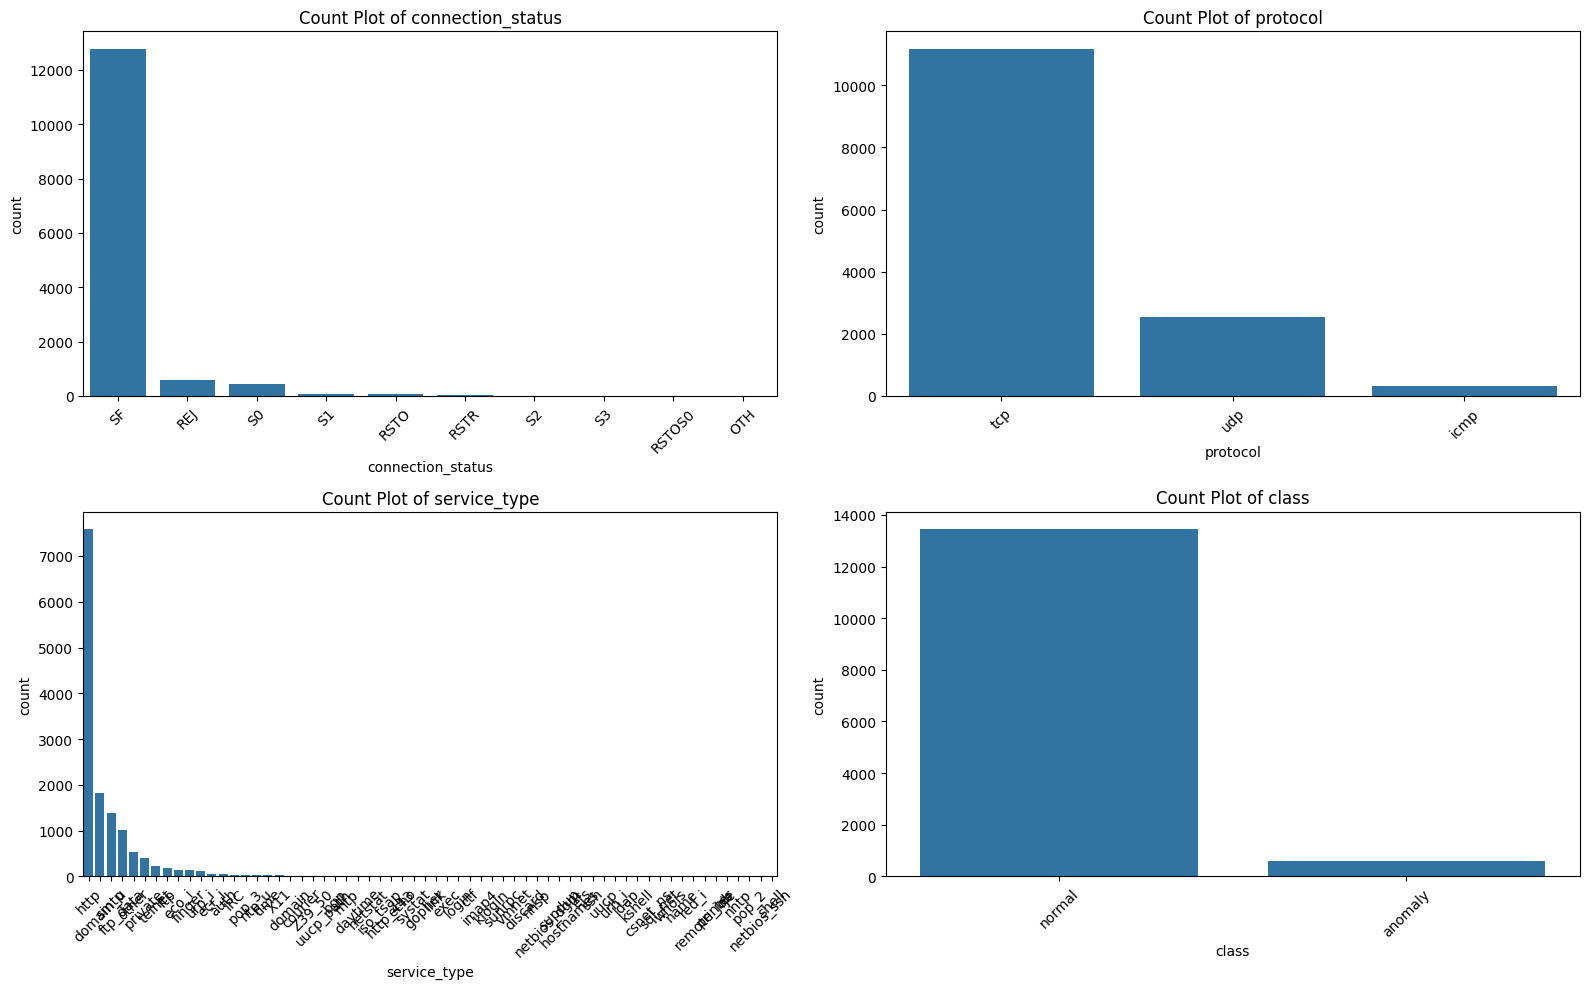

In [18]:


n_cols = 2


n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(16, 5 * n_rows))

for i, col in enumerate(cat_cols):
    
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.countplot(
        x=df[col],
        order=df[col].value_counts().index
    )
    
    plt.title(f'Count Plot of {col}')
    
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

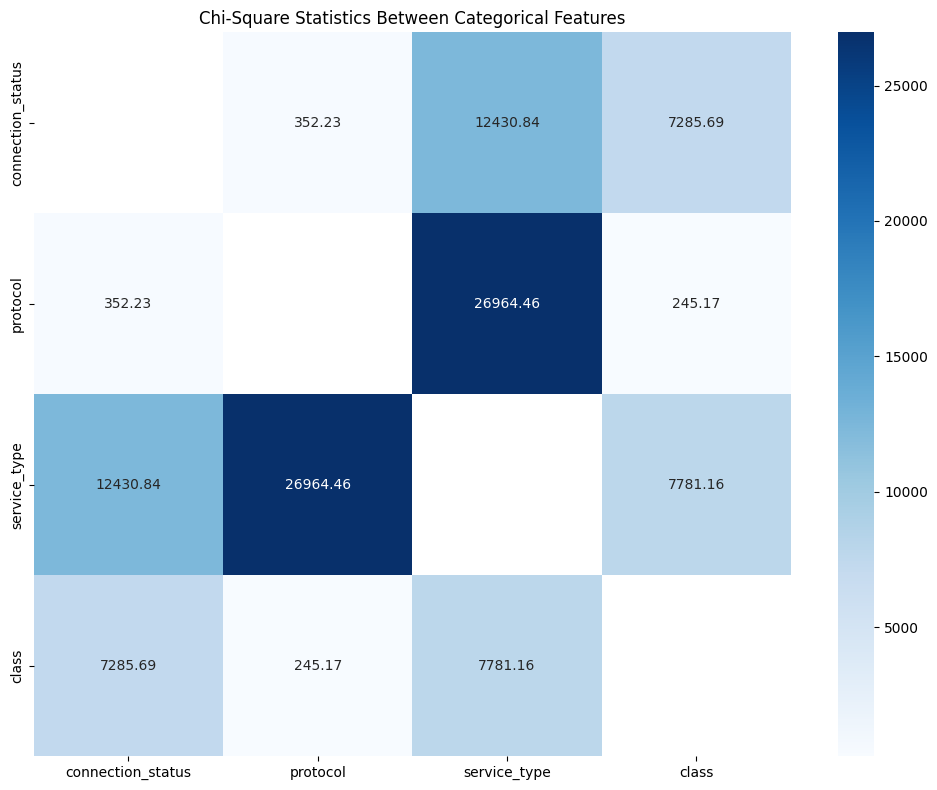

In [19]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


chi_scores = pd.DataFrame(index=cat_cols, columns=cat_cols)


for col1 in cat_cols:
    for col2 in cat_cols:
        
       
        if col1 == col2:
            chi_scores.loc[col1, col2] = np.nan
            continue
        
        
        contingency = pd.crosstab(df[col1], df[col2])
        
       
        chi2, p, dof, expected = chi2_contingency(contingency)
        
        
        chi_scores.loc[col1, col2] = chi2


chi_scores = chi_scores.astype(float)

plt.figure(figsize=(10, 8))

sns.heatmap(
    chi_scores,
    annot=True,
    cmap='Blues',
    fmt=".2f"
)

plt.title("Chi-Square Statistics Between Categorical Features")

plt.tight_layout()
plt.show()



# Feature Selection and Dimensionality Reduction Report

### Overview

The objective of this feature reduction is to eliminate redundant information (multicollinearity), remove features that provide no predictive value (near-zero variance), and simplify the dataset to prevent model overfitting. The features below are grouped by the statistical reason for their removal.

### 1. Features Dropped Due to Categorical Dominance (High $\eta$ Ratio)

The Correlation Ratio ($\eta$) measures the relationship between a categorical variable and a numerical variable. An $\eta$ score above 0.90 indicates that the categorical variable almost entirely dictates the value of the numerical variable. Keeping both introduces severe redundancy.

We will keep the summarizing categorical variables (`connection_status`, `service_type`) and drop the numerical variables they fully explain.

* **`reset_error_rate`**: Dropped. It has an $\eta$ of 0.98 with `connection_status`. Knowing the connection status provides the exact same information to the model.
* **`server_reset_error_rate`**: Dropped. It has an $\eta$ of 0.98 with `connection_status`.
* **`syn_error_rate`**: Dropped. It has an $\eta$ of 0.94 with `connection_status`.
* **`server_syn_error_rate`**: Dropped. It has an $\eta$ of 0.93 with `connection_status`.
* **`destination_server_reset_error_rate`**: Dropped. It has an $\eta$ of 0.90 with `connection_status`.
* **`guest_login`**: Dropped. It has an $\eta$ of 0.95 with `service_type`. The type of service inherently defines whether the interaction is a guest login, making this column unnecessary.

### 2. Features Dropped Due to Multicollinearity (Spearman Correlation)

The Spearman correlation matrix identifies numerical features that have a strictly monotonic relationship. A correlation above 0.85 (or below -0.85) means the two features move together almost perfectly. We must drop one feature from each highly correlated pair to ensure stable model weights and accurate feature importance scores.

* **`same_server_rate`**: Dropped. It has a -0.96 correlation with `different_server_rate`. These are exact mathematical opposites. Retain `different_server_rate` and drop this one.
* **`destination_same_server_rate`**: Dropped. It has a 0.86 correlation with `destination_host_server_count`. Retaining both provides duplicated scaling vectors to the model.
* **`server_request_count`**: Dropped. It has a 0.85 correlation with `connection_count`. We will retain `connection_count` as the primary metric for volume and drop the redundant server request count.

*(Note: The Spearman matrix also flagged `syn_error_rate` and `server_syn_error_rate` as highly correlated with each other (0.91), but both are already being dropped due to categorical dominance in section 1).*

### 3. Features Dropped Due to Near-Zero Variance and Low Predictive Power

Features that consist almost entirely of a single value (usually zero) do not provide the model with any patterns to learn from. When evaluated against the target variable (`class`), these features yield an $\eta$ score of less than 0.01, confirming they have no statistical significance in separating the classes.

* **`source_bytes`**: Dropped. The histograms and boxplots show massive zero-inflation with isolated extreme outliers. The $\eta$ ratio against the `class` target is 0.001, meaning this column contributes mathematically zero predictive power.
* **`suspicious_activity`**: Dropped. The scatter plots confirm this feature is functionally a flat line at zero. Its $\eta$ with `class` is 0.005.
* **`compromised_count`**: Dropped. Similar to suspicious activity, it exhibits near-zero variance and an $\eta$ of 0.005 with the target.

---

### Implementation Summary

For your data preprocessing pipeline, you can safely execute the following drop command to clean the dataset before scaling or training:

```python
columns_to_drop = [
    'reset_error_rate', 
    'server_reset_error_rate', 
    'syn_error_rate', 
    'server_syn_error_rate', 
    'destination_server_reset_error_rate', 
    'guest_login',
    'same_server_rate',
    'destination_same_server_rate',
    'server_request_count',
    'source_bytes',
    'suspicious_activity',
    'compromised_count'
]

df_cleaned = df.drop(columns=columns_to_drop)

```

In [20]:
columns_to_drop = [
    'reset_error_rate', 
    'server_reset_error_rate', 
    'syn_error_rate', 
    'server_syn_error_rate', 
    'destination_server_reset_error_rate', 
    'guest_login',
    'same_server_rate',
    'destination_same_server_rate',
    'server_request_count',
    'source_bytes',
    'suspicious_activity',
    'compromised_count'
]

df_cleaned = df.drop(columns=columns_to_drop)

In [21]:
df_cleaned.to_csv('../data/cleaned_data.csv', index=False)